In [137]:
# ===============================
# Import Libraries
# ===============================

import os
import warnings

import joblib
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBRegressor
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

warnings.filterwarnings("ignore")

In [138]:
path = kagglehub.dataset_download(
    "nalisha/tesla-ea-deliveries-and-production-data20152025"
)

print(path)

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025


In [139]:
csv_file = [f for f in os.listdir(path) if f.endswith(".csv")][0]

df = pd.read_csv(os.path.join(path,csv_file))

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [140]:
df.shape

df.info()

df.describe()

df.isnull().sum()

df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


np.int64(0)

In [141]:
df.drop_duplicates(inplace=True)

num_cols=df.select_dtypes(include=np.number).columns

df[num_cols]=df[num_cols].fillna(df[num_cols].median())

cat_cols=df.select_dtypes(include='object').columns

df[cat_cols]=df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [142]:
# ==============================
# Feature Engineering
# ==============================

df['Delivery_Production_Ratio'] = (
    df['Estimated_Deliveries'] / df['Production_Units']
)

df['Price_per_kWh'] = (
    df['Avg_Price_USD'] / df['Battery_Capacity_kWh']
)

df['Efficiency_km_per_kWh'] = (
    df['Range_km'] / df['Battery_Capacity_kWh']
)

df['CO2_per_Delivery'] = (
    df['CO2_Saved_tons'] / df['Estimated_Deliveries']
)

df['Quarter'] = ((df['Month'] - 1) // 3) + 1

df['Year_Month'] = df['Year'] * 100 + df['Month']

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Delivery_Production_Ratio,Price_per_kWh,Efficiency_km_per_kWh,CO2_per_Delivery,Quarter,Year_Month
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,0.984600,773.952250,5.866667,0.105600,2,202305
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,0.911864,829.408667,5.840000,0.065699,1,201502
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,0.915334,1437.650244,5.853659,0.072000,1,201901
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,0.896594,744.124250,5.933333,0.106799,1,202102
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,0.914087,957.056500,5.508333,0.099150,4,201612


<Axes: xlabel='Year', ylabel='Estimated_Deliveries'>

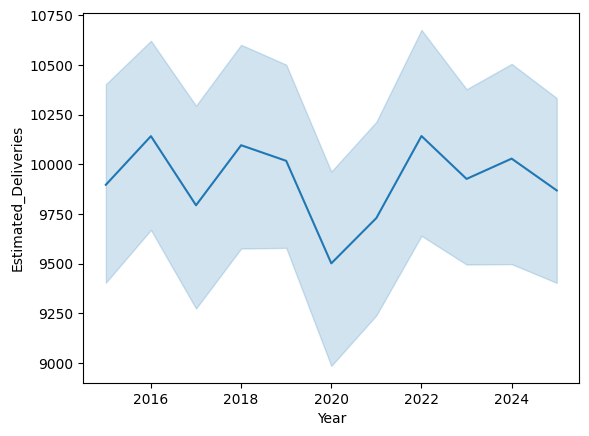

In [143]:
sns.lineplot(data=df,x='Year',y='Estimated_Deliveries')

<Axes: xlabel='Year', ylabel='Production_Units'>

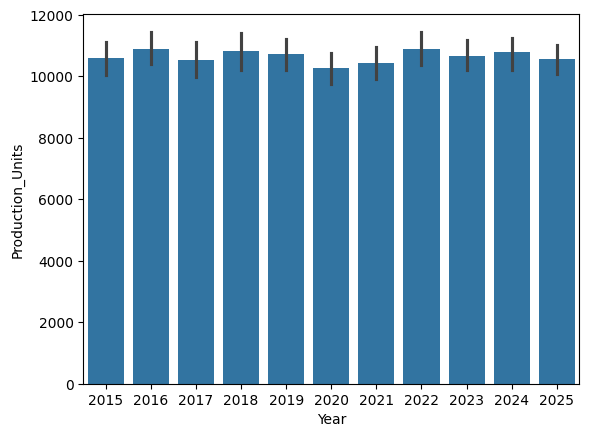

In [144]:
sns.barplot(data=df,x='Year',y='Production_Units')

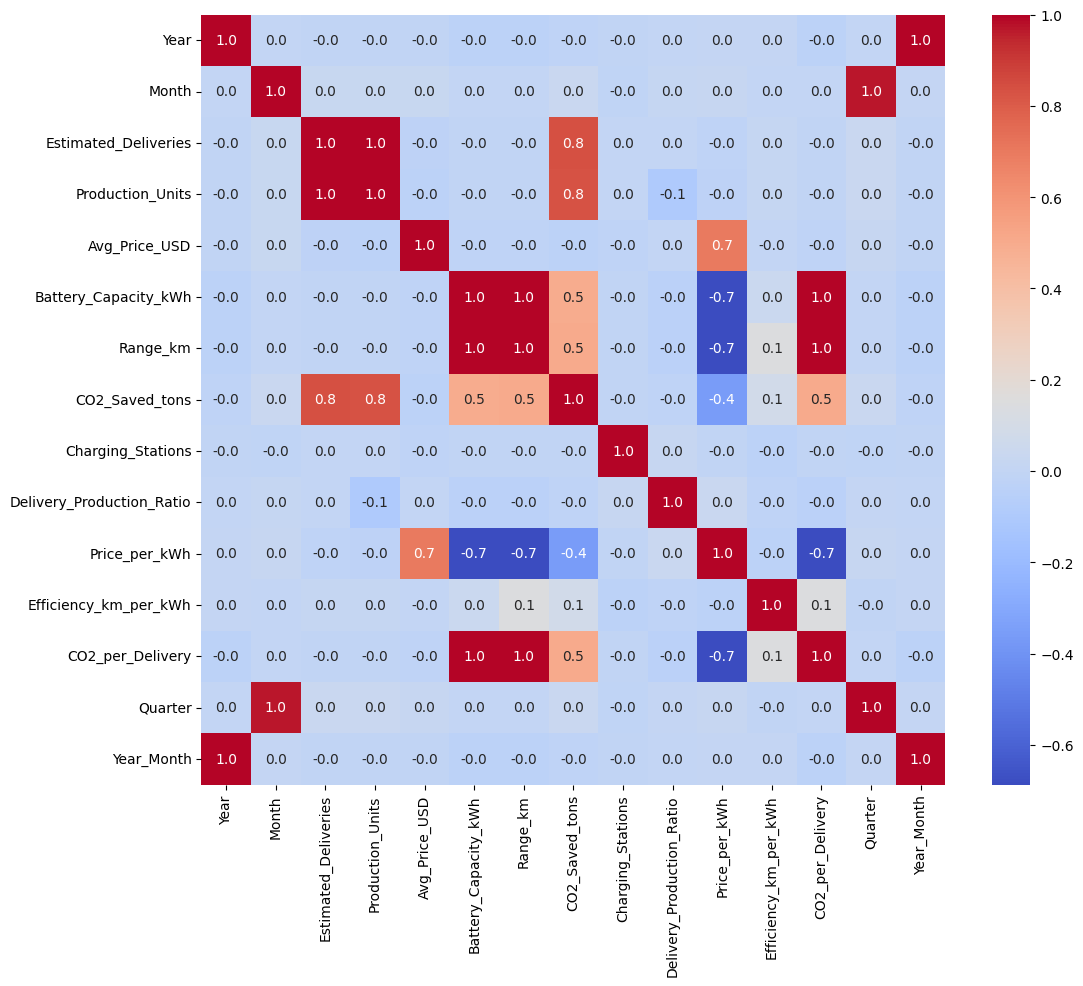

In [147]:
# 1. Adjust the figure size to make the plot larger
plt.figure(figsize=(12, 10))

# 2. Add fmt=".1f" to limit decimal places and reduce clutter
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".1f", cmap='coolwarm')

# 3. Display the plot
plt.show()

<Axes: xlabel='Region', ylabel='Estimated_Deliveries'>

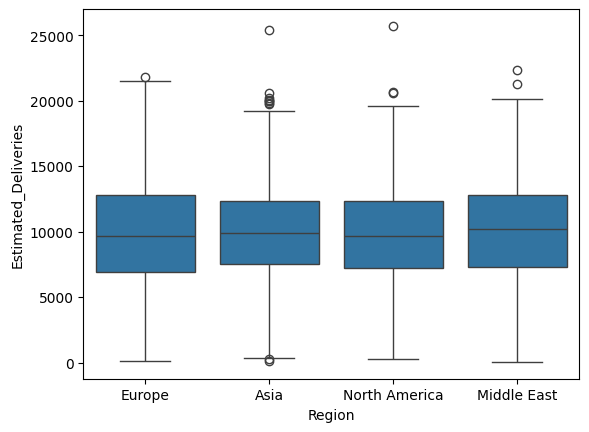

In [109]:
sns.boxplot(data=df,x='Region',y='Estimated_Deliveries')

<Axes: xlabel='Model'>

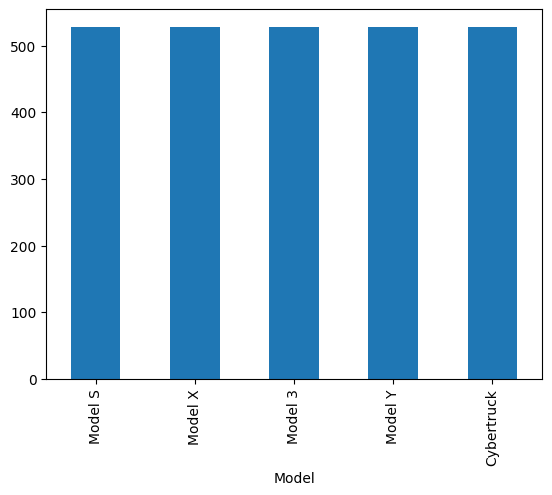

In [110]:
df['Model'].value_counts().plot(kind='bar')

In [112]:
# Target variable
y = df['Avg_Price_USD']

# Feature variables
X = df.drop(columns=['Avg_Price_USD'])

In [113]:
print(X.shape)
print(y.shape)

X.head()

(2640, 17)
(2640,)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Delivery_Production_Ratio,Price_per_kWh,Efficiency_km_per_kWh,CO2_per_Delivery,Quarter,Year_Month
0,2023,5,Europe,Model S,17646,17922,120,704,1863.42,Interpolated (Month),12207,0.984600,773.952250,5.866667,0.105600,2,202305
1,2015,2,Asia,Model X,3797,4164,75,438,249.46,Official (Quarter),7640,0.911864,829.408667,5.840000,0.065699,1,201502
2,2019,1,North America,Model X,8411,9189,82,480,605.59,Interpolated (Month),14071,0.915334,1437.650244,5.853659,0.072000,1,201901
3,2021,2,North America,Model 3,6555,7311,120,712,700.07,Official (Quarter),9333,0.896594,744.124250,5.933333,0.106799,1,202102
4,2016,12,Middle East,Model Y,12374,13537,120,661,1226.88,Estimated (Region),8722,0.914087,957.056500,5.508333,0.099150,4,201612


In [114]:
# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Numeric preprocessing
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [115]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [118]:
# ==============================
# Define Features and Target
# ==============================

y = df['Avg_Price_USD']
X = df.drop(columns=['Avg_Price_USD'])

# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Numeric preprocessing
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Complete preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print("Preprocessing pipeline created successfully!")
print("\nNumeric Features:")
print(list(numeric_features))

print("\nCategorical Features:")
print(list(categorical_features))

Preprocessing pipeline created successfully!

Numeric Features:
['Year', 'Month', 'Estimated_Deliveries', 'Production_Units', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'Delivery_Production_Ratio', 'Price_per_kWh', 'Efficiency_km_per_kWh', 'CO2_per_Delivery', 'Quarter', 'Year_Month']

Categorical Features:
['Region', 'Model', 'Source_Type']


In [119]:
lr=Pipeline([
('prep',preprocessor),
('model',LinearRegression())
])

lr.fit(X_train,y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Year', 'Month', 'Estimated_Deliveries', 'Production_Units',
       'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
       'Charging_Stations', 'Delivery_Production_Ratio', 'Price_per_kWh',
       'Efficiency_km_per_kWh', 'CO2_per_Delivery', 'Quarter', 'Year_Month'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Region', 'Model', 'Source_Type'], dtype='object'))])),
                ('model', LinearRegression())])

Linear Regression Performance
-----------------------------------
MAE : 4911.108191867908
RMSE: 6041.236028422066
R² Score: 0.9032211609894445


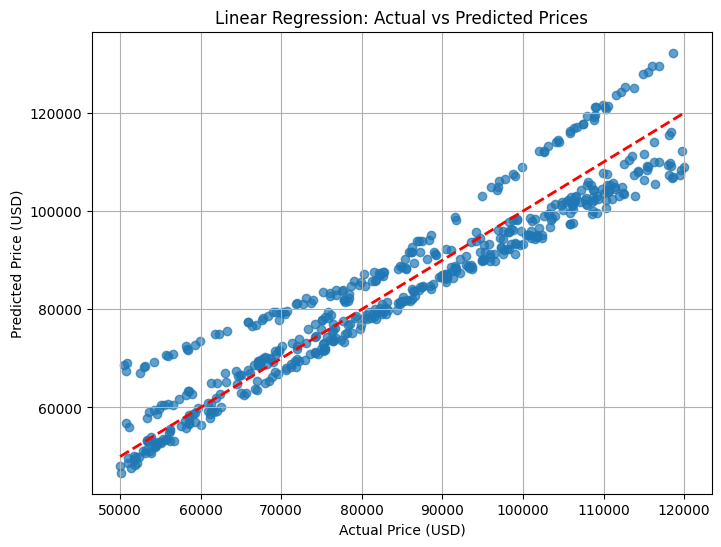

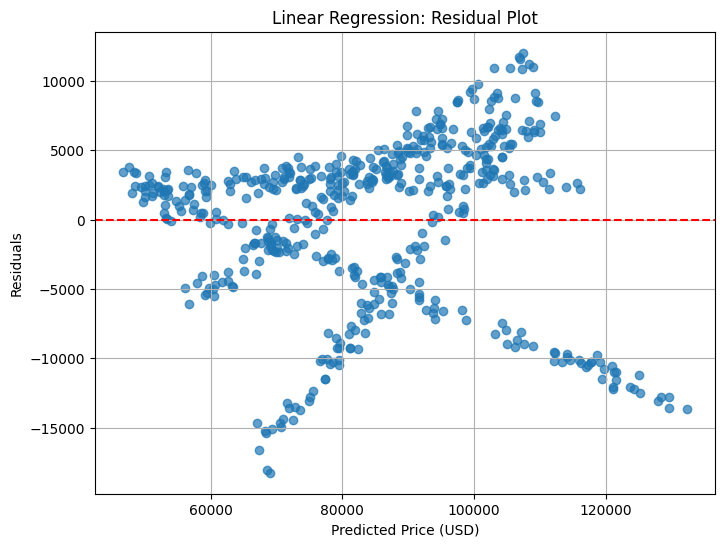

In [135]:
# Predictions using Linear Regression
pred = lr.predict(X_test)

# Evaluation Metrics
print("Linear Regression Performance")
print("-" * 35)
print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R² Score:", r2_score(y_test, pred))

# Actual vs Predicted Plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, pred, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)
plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")
plt.title("Linear Regression: Actual vs Predicted Prices")
plt.grid(True)
plt.show()

# Residual Plot
residuals = y_test - pred

plt.figure(figsize=(8,6))
plt.scatter(pred, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Price (USD)")
plt.ylabel("Residuals")
plt.title("Linear Regression: Residual Plot")
plt.grid(True)
plt.show()

In [121]:
rf=Pipeline([
('prep',preprocessor),
('model',RandomForestRegressor(random_state=42))
])

rf.fit(X_train,y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Year', 'Month', 'Estimated_Deliveries', 'Production_Units',
       'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
       'Charging_Stations', 'Delivery_Production_Ratio', 'Price_per_kWh',
       'Efficiency_km_per_kWh', 'CO2_per_Delivery', 'Quarter', 'Year_Month'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Region', 'Model', 'Source_Type'], dtype='object'))])),
                ('model', RandomForestRegressor(random_state=42))])

In [122]:
params={
'model__n_estimators':[100,200],
'model__max_depth':[5,10,None]
}

grid=GridSearchCV(
rf,
params,
cv=5,
scoring='r2'
)

grid.fit(X_train,y_train)

grid.best_params_

{'model__max_depth': None, 'model__n_estimators': 200}

In [123]:
xgb=Pipeline([
('prep',preprocessor),
('model',XGBRegressor())
])

xgb.fit(X_train,y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Year', 'Month', 'Estimated_Deliveries', 'Production_Units',
       'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
       'Charging_Stations', 'Delivery_Production_Ratio', 'Price_per_kWh',
       'Efficiency_km_pe...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, ...))])

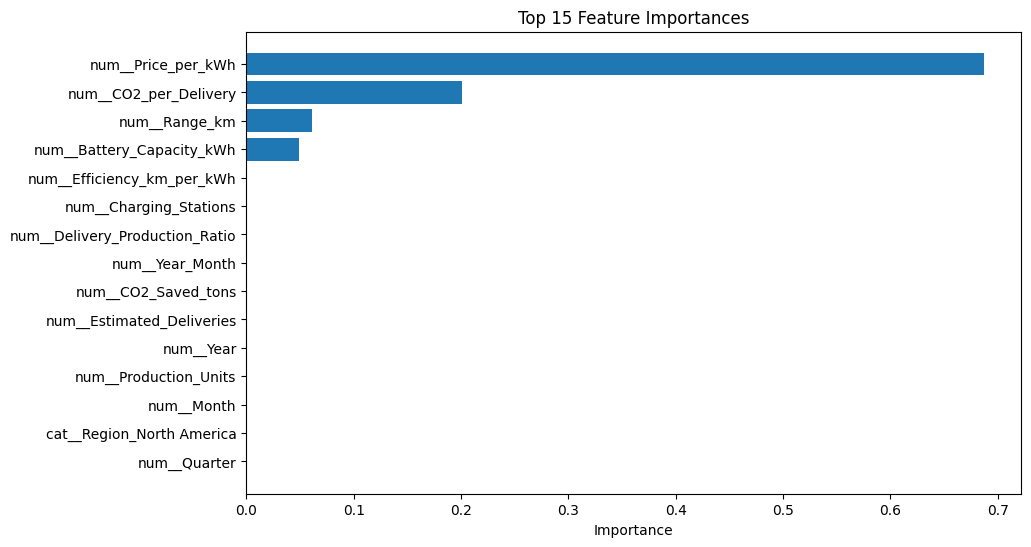

,Feature,Importance
9,num__Price_per_kWh,0.687677
11,num__CO2_per_Delivery,0.201345
5,num__Range_km,0.060778
4,num__Battery_Capacity_kWh,0.049083
10,num__Efficiency_km_per_kWh,0.000572
7,num__Charging_Stations,0.000087
8,num__Delivery_Production_Ratio,0.000058
13,num__Year_Month,0.000056
6,num__CO2_Saved_tons,0.000055
2,num__Estimated_Deliveries,0.000051


In [125]:
# Get the best Random Forest model
best_rf = grid.best_estimator_.named_steps['model']

# Get transformed feature names
feature_names = grid.best_estimator_.named_steps['prep'].get_feature_names_out()

# Get feature importance
importance = best_rf.feature_importances_

# Create DataFrame
importance_df = (
    pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    })
    .sort_values(by='Importance', ascending=False)
)

# Plot Top 15 Features
plt.figure(figsize=(10,6))

plt.barh(
    importance_df['Feature'][:15],
    importance_df['Importance'][:15]
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.gca().invert_yaxis()

plt.show()

# Display the table
importance_df.head(15)

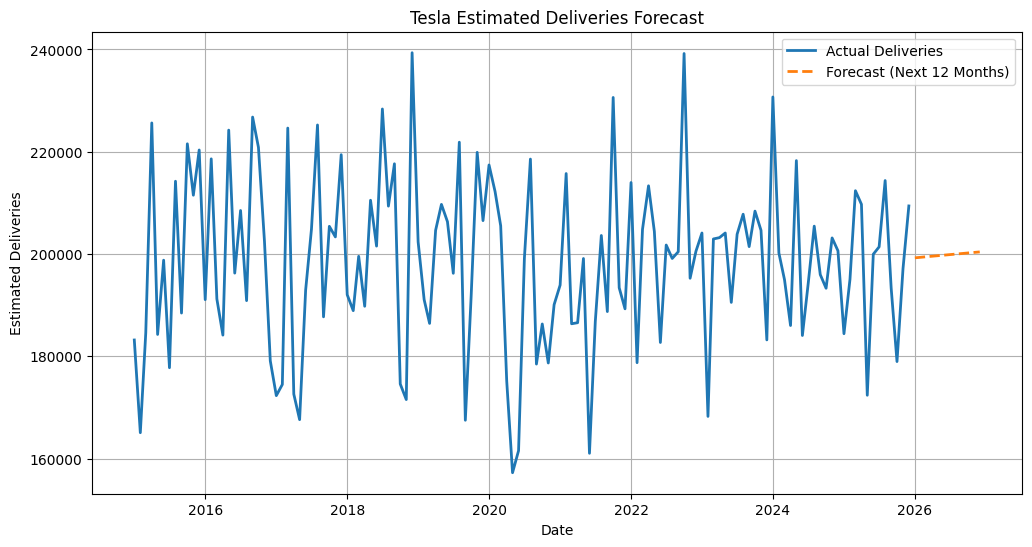


Forecast for Next 12 Months:


,Forecast_Date,Predicted_Deliveries
0,2026-01-01,199247
1,2026-02-01,199352
2,2026-03-01,199458
3,2026-04-01,199563
4,2026-05-01,199668
5,2026-06-01,199773
6,2026-07-01,199878
7,2026-08-01,199983
8,2026-09-01,200088
9,2026-10-01,200193


In [133]:
# ===============================
# Time Series Forecasting
# ===============================
# Create monthly time series
monthly = (
    df.groupby(['Year', 'Month'])['Estimated_Deliveries']
      .sum()
      .reset_index()
)

# Create Date column
monthly['Date'] = pd.to_datetime(
    monthly[['Year', 'Month']].assign(day=1)
)

# Set Date as index
monthly.set_index('Date', inplace=True)

# Fit Exponential Smoothing model
model = ExponentialSmoothing(
    monthly['Estimated_Deliveries'],
    trend='add',
    seasonal=None
).fit()

# Forecast next 12 months
forecast = model.forecast(12)

# Create future dates
future_dates = pd.date_range(
    start=monthly.index[-1] + pd.DateOffset(months=1),
    periods=12,
    freq='MS'
)

forecast.index = future_dates

# Plot
plt.figure(figsize=(12,6))

plt.plot(
    monthly.index,
    monthly['Estimated_Deliveries'],
    label='Actual Deliveries',
    linewidth=2
)

plt.plot(
    forecast.index,
    forecast,
    '--',
    label='Forecast (Next 12 Months)',
    linewidth=2
)

plt.title('Tesla Estimated Deliveries Forecast')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.grid(True)

plt.show()

# Display forecast values
forecast_df = pd.DataFrame({
    'Forecast_Date': forecast.index,
    'Predicted_Deliveries': forecast.values.astype(int)
})

print("\nForecast for Next 12 Months:")
display(forecast_df)

In [134]:
joblib.dump(grid.best_estimator_, "tesla_price_model.pkl")

print("Best model saved as tesla_price_model.pkl")

Best model saved as tesla_price_model.pkl


# Conclusion

This project successfully developed an end-to-end machine learning pipeline using Tesla sales and production data. The workflow included data loading, preprocessing, exploratory data analysis (EDA), feature engineering, regression modeling, hyperparameter tuning, and time series forecasting.

## Key Outcomes

- Cleaned and prepared the dataset by handling missing values, duplicates, and appropriate data types.
- Performed exploratory data analysis to identify trends, relationships, and distributions among key variables.
- Engineered meaningful features such as Delivery-to-Production Ratio, Price per kWh, Vehicle Efficiency, Quarter, and CO₂ Saved per Delivery to improve model performance.
- Built and compared multiple regression models, including Linear Regression, Random Forest, and XGBoost, for predicting average vehicle price.
- Applied hyperparameter tuning using GridSearchCV to optimize model performance.
- Evaluated models using MAE, RMSE, and R² score to select the best-performing model.
- Forecasted Tesla's estimated deliveries for the next 12 months using the Exponential Smoothing time series model.

## Business Insights

- Tesla deliveries have shown a generally increasing trend over time.
- Battery capacity and vehicle range are important factors influencing vehicle pricing.
- The engineered features provide additional insights into production efficiency and sustainability.
- The forecasting model indicates expected future delivery trends, which can support production planning and business decision-making.

